# Proyecto Clasificación de Textos 
## Parte 1: Machine Learning Clásico

Este Jupyter Notebook contiene el flujo de predicción para la competencia de aprendizaje de máquinas para predecir la década a la que pertenece un texto basándonos en los laboratorios de clase.

In [1]:
import pandas as pd
import numpy as np
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib
import warnings
warnings.filterwarnings("ignore")

import re
import matplotlib.pyplot as plt


### 1. Carga de los Datos
Revisamos los datos brindados en la competencia, `train.csv` y `eval.csv`. Asegúrate de que los archivos se encuentren en el mismo directorio del Notebook.

In [2]:
print("Cargando dataset...")
try:
    df_train = pd.read_csv("./data/train.csv")
    df_eval = pd.read_csv("./data/eval.csv")
    print("Datos cargados. Entrenamos con:", len(df_train), "registros.")
except FileNotFoundError:
    print("Error: Descarga los archivos train.csv y eval.csv acá primero.")


Cargando dataset...
Datos cargados. Entrenamos con: 31403 registros.


### 2. Procesamiento y Limpieza Textual (NLTK)
Siguiendo el laboratorio, utilizaremos tokenización, minúsculas, y truncaremos la palabra con Stemmer.

In [3]:
#nltk.download("punkt")
#nltk.download("punkt_tab")
stemmer = PorterStemmer()

print("Iniciando limpieza textual de Train y Eval...")
# Reemplazamos los signos raros y de puntuación por espacios
# Para el caractér "-" que indica la contuniadad de una pabra el la siguiente línea hacemos una excepción y lo eliminamos
df_train["clean_text"] = df_train["text"].str.lower()
df_train["clean_text"] = df_train["clean_text"].str.replace(r"-\s*\n\s*","",regex=True)
df_train["clean_text"] = df_train["clean_text"].str.replace(r"[^a-zA-ZáéíóúÁÉÍÓÚñÑ\s]"," ",regex=True)

df_eval["clean_text"] = df_train["text"].str.lower()
df_eval["clean_text"] = df_eval["clean_text"].str.replace(r"-\s*\n\s*","",regex=True)
df_eval["clean_text"] = df_eval["clean_text"].str.replace(r"[^a-zA-ZáéíóúÁÉÍÓÚñÑ\s]"," ",regex=True)
# Arreglamos los espacios para que solo quede uno
df_train["clean_text"] = df_train["clean_text"].str.replace(r"\s+", " ", regex=True).str.strip()
df_eval["clean_text"] = df_eval["clean_text"].str.replace(r"\s+", " ", regex=True).str.strip()


def token_y_stem(text):
    tokens = word_tokenize(text)
    return " ".join([stemmer.stem(t) for t in tokens if t.isalnum()])

df_train["clean_text"] = df_train["clean_text"].apply(token_y_stem)
df_eval["clean_text"] = df_eval["clean_text"].apply(token_y_stem)

print("¡Textos procesados!")
df_train.head(3)

Iniciando limpieza textual de Train y Eval...
¡Textos procesados!


,text,decade,clean_text
0,\nHonorarias ¡jubiladas. 57 \ndit.ad Pontem de...,164,honoraria jubilada dit ad pontem de poreft pro...
1,"gone. Sus amigos , sus clientes, todo \ncuanto...",182,gone su amigo su client todo cuanto le rodea l...
2,"Prefosen quemanera,e per qualesfolpechas deuan...",157,prefosen quemanera e per qualesfolpecha deuan ...


In [4]:
df_train["clean_text"][0]

'honoraria jubilada dit ad pontem de poreft proreg m pag ste ph gratian difcept áqu len ne parec que aísilt o ayuda calsiodoro lib epuft s dond llama ocloso cingv y'

### 3. Representación Vectorial (Vectorización TF-IDF)
Usando los conceptos de la clase, se usará `TfidfVectorizer` agregando bigramas y excluyendo stop words.

In [5]:
stopwords_es = ["yo","mi","conmigo","tú","ti","contigo","vos","él","ella","ello","usted","sí","consigo","nosotros","nosotras","ellos",
                "ellas","ustedes","me","te","nos","lo","la","se","los","las","les","mía","mío","míos","mías","tuyo","tuya","tuyos","tuyas",
                "suyo","suya","suyos","suyas","nuestro","nuestra","nuestros","nuestras","este","esta","esto","estos","estas","ese","eso",
                "esa","esos","esas","aquel","aquello","aquella","aquellos","aquellas","uno","una","unos","unas","otro","otra","otros","otras",
                "cualquiera","cualesquiera","quienquiera","quienesquiera","demás","de","que","en","por","con","del","para","como","pues",
                "pero","porque","muy","mas","era","parte","donde","no","ni","ya","es","al","le","su","ha","si","sus","fue","quien","el","entre",
                "un","bien","dos","tu","don","tiempo"]

vectorizador = TfidfVectorizer(max_features=25000, stop_words=stopwords_es, max_df=0.8, ngram_range=(1,3))

print("Construyendo matriz TF-IDF...")
X = vectorizador.fit_transform(df_train["clean_text"])
y = df_train["decade"]
print("Matriz terminada")

# Split local temporal para ver qué tan bueno es
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

Construyendo matriz TF-IDF...
Matriz terminada


In [6]:
doc_vector = X[0].toarray().flatten()

df_importancia = pd.DataFrame({
    "palabra": vectorizador.get_feature_names_out(),
    "peso": doc_vector
})

df_importancia = df_importancia.sort_values(by="peso", ascending=False)

df_importancia.head()

,palabra,peso
18368,poreft,0.384505
17931,ph,0.350882
21727,ste,0.349435
13435,len,0.321798
6689,dit,0.321044


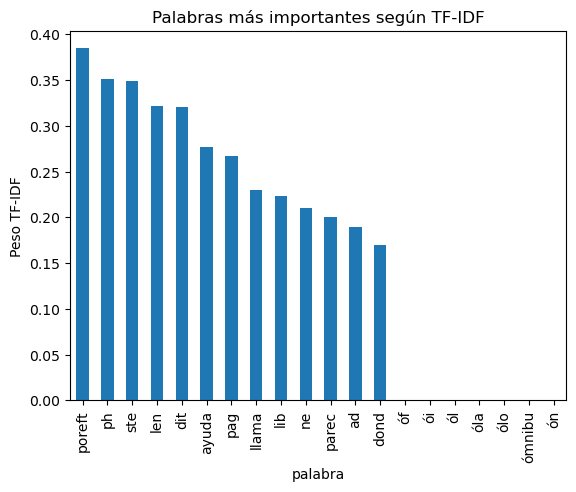

In [7]:
df_importancia.head(20).plot.bar(x="palabra", y="peso", legend=False)

plt.title("Palabras más importantes según TF-IDF")
plt.ylabel("Peso TF-IDF")
plt.show()

### 4. Construcción del Modelo Clásico
Probaremos `SGDClassifier`, que suele dominar entre los sistemas clásicos para NLP (implementa Regresión Lineal/Logística robusta y rápida).

In [8]:
modelo_val = SGDClassifier(loss="log_loss", alpha=1e-4, max_iter=2000, random_state=42)
modelo_val.fit(X_train, y_train)

y_pred_val = modelo_val.predict(X_test)
print("Métricas Locales (Opcional):")
print(classification_report(y_test, y_pred_val))
print("Accuracy Local:", accuracy_score(y_test, y_pred_val))


Métricas Locales (Opcional):
              precision    recall  f1-score   support

         150       0.38      0.67      0.49       116
         151       0.28      0.48      0.35       127
         152       0.42      0.57      0.48       137
         153       0.22      0.38      0.28       116
         154       0.34      0.45      0.39       126
         155       0.18      0.10      0.13       133
         156       0.33      0.35      0.34       116
         157       0.13      0.13      0.13       117
         158       0.18      0.17      0.17       115
         159       0.12      0.22      0.15       108
         160       0.08      0.05      0.06       130
         161       0.15      0.04      0.07       115
         162       0.27      0.17      0.21       136
         163       0.15      0.13      0.14       113
         164       0.14      0.12      0.13       119
         165       0.10      0.05      0.06       127
         166       0.05      0.01      0.01       11

### 5. Predicción Final y Respuesta Kaggle
Ajustamos nuevamente al total de datos para no perder esa información y exportamos.

In [ ]:
modelo_final = SGDClassifier(loss="log_loss", alpha=1e-4, max_iter=2000, random_state=42)
modelo_final.fit(X, y)

print("Realizando predicciones finales...")
X_eval = vectorizador.transform(df_eval["texto_limpio"])
predicciones = modelo_final.predict(X_eval)

df_eval["answer"] = predicciones
submission = df_eval[["id", "answer"]]
submission.to_csv("submission.csv", index=False)
print("¡Archivo guardado como submission.csv! Listo para Kaggle.")


### 6. Guardar el Modelo (Requerimiento de la clase para Bloque Neón)

In [ ]:
print("Guardando modelos usando Joblib...")
joblib.dump(modelo_final, "modelo_clasificador.joblib")
joblib.dump(vectorizador, "vectorizador.joblib")
print("Archivo de modelos guardados (entregables válidos).")
